## Topology_A duration


=== Final Results ===
b1: F1-Score = 0.1196, Std = 0.0110
b2: F1-Score = 0.1297, Std = 0.0116
b3: F1-Score = 0.1804, Std = 0.0267
b4: F1-Score = 0.2514, Std = 0.0225
b5: F1-Score = 0.3495, Std = 0.0160
b6: F1-Score = 0.4449, Std = 0.0242
b7: F1-Score = 0.6302, Std = 0.0305
b8: F1-Score = 0.6315, Std = 0.0232
b9: F1-Score = 0.6234, Std = 0.0226
b10: F1-Score = 0.6297, Std = 0.0214
b11: F1-Score = 0.6343, Std = 0.0212
b12: F1-Score = 0.6376, Std = 0.0216
b13: F1-Score = 0.6421, Std = 0.0216
b14: F1-Score = 0.6436, Std = 0.0223
b15: F1-Score = 0.6438, Std = 0.0220
b16: F1-Score = 0.6440, Std = 0.0220
b17: F1-Score = 0.6440, Std = 0.0219
b18: F1-Score = 0.6440, Std = 0.0219
b19: F1-Score = 0.6440, Std = 0.0219
b20: F1-Score = 0.6440, Std = 0.0219
b21: F1-Score = 0.6440, Std = 0.0219
b22: F1-Score = 0.6440, Std = 0.0219
b23: F1-Score = 0.6440, Std = 0.0219
b24: F1-Score = 0.6440, Std = 0.0219
b25: F1-Score = 0.6440, Std = 0.0219
b26: F1-Score = 0.6440, Std = 0.0219
b27: F1-Score = 0.6440, 

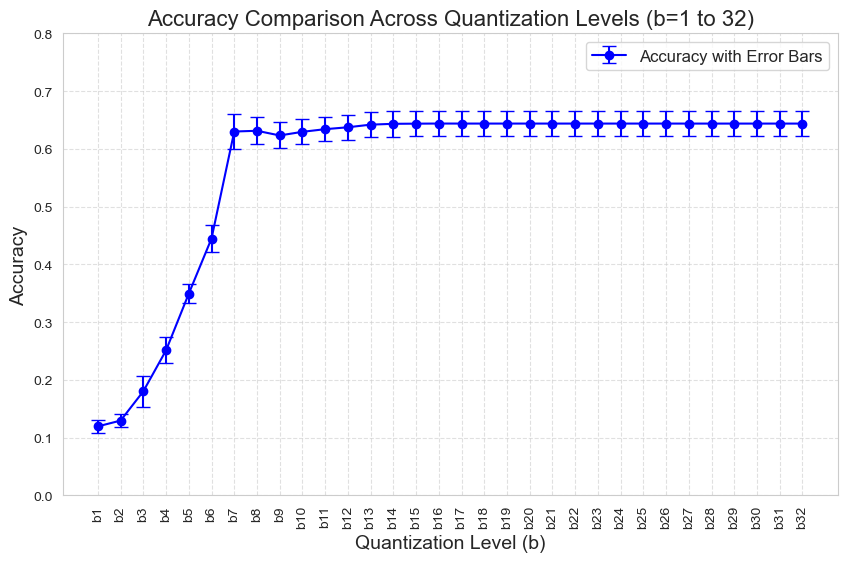

In [14]:
# classification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name","Average IAT"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name","Average IAT"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        F1_sc = f1_score(y_test_quantized, y_pred, average='macro')
        accuracies_per_file[file_name].append(F1_sc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: F1-Score = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 0.8)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results ===
b1: F1-Score = 0.1338, Std = 0.0159
b2: F1-Score = 0.1434, Std = 0.0114
b3: F1-Score = 0.1613, Std = 0.0145
b4: F1-Score = 0.2027, Std = 0.0250
b5: F1-Score = 0.2751, Std = 0.0281
b6: F1-Score = 0.3513, Std = 0.0446
b7: F1-Score = 0.5229, Std = 0.0660
b8: F1-Score = 0.5760, Std = 0.0359
b9: F1-Score = 0.6126, Std = 0.0262
b10: F1-Score = 0.6425, Std = 0.0414
b11: F1-Score = 0.6553, Std = 0.0385
b12: F1-Score = 0.6557, Std = 0.0463
b13: F1-Score = 0.6625, Std = 0.0436
b14: F1-Score = 0.6652, Std = 0.0419
b15: F1-Score = 0.6626, Std = 0.0409
b16: F1-Score = 0.6658, Std = 0.0406
b17: F1-Score = 0.6684, Std = 0.0402
b18: F1-Score = 0.6713, Std = 0.0417
b19: F1-Score = 0.6736, Std = 0.0418
b20: F1-Score = 0.6737, Std = 0.0419
b21: F1-Score = 0.6737, Std = 0.0405
b22: F1-Score = 0.6737, Std = 0.0404
b23: F1-Score = 0.6736, Std = 0.0404
b24: F1-Score = 0.6736, Std = 0.0404
b25: F1-Score = 0.6736, Std = 0.0404
b26: F1-Score = 0.6736, Std = 0.0404
b27: F1-Score = 0.6736, 

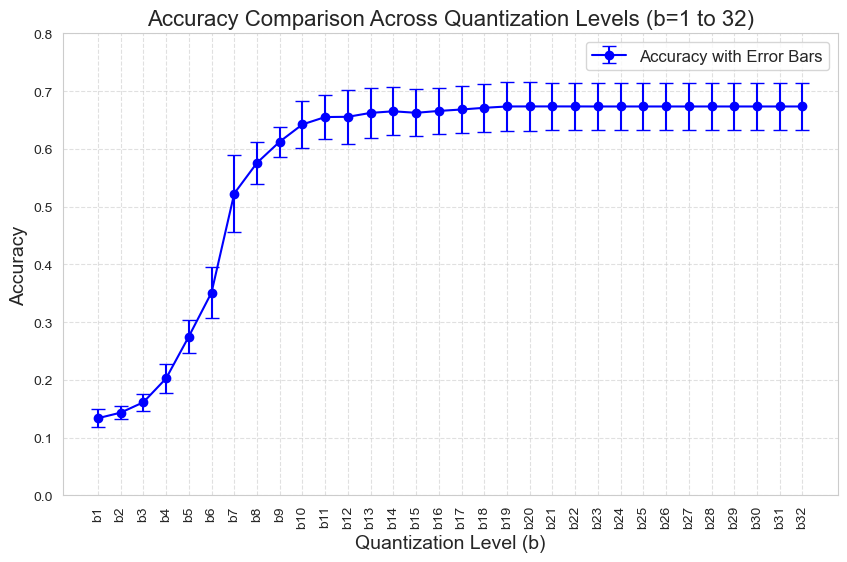

In [15]:
# classification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        F1_sc = f1_score(y_test_quantized, y_pred, average='macro')
        accuracies_per_file[file_name].append(F1_sc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: F1-Score = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 0.8)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results ===
b1: F1-Score = 0.0327, Std = 0.0068
b2: F1-Score = 0.0276, Std = 0.0018
b3: F1-Score = 0.0432, Std = 0.0029
b4: F1-Score = 0.1020, Std = 0.0138
b5: F1-Score = 0.1750, Std = 0.0186
b6: F1-Score = 0.2497, Std = 0.0169
b7: F1-Score = 0.3162, Std = 0.0240
b8: F1-Score = 0.3702, Std = 0.0133
b9: F1-Score = 0.3959, Std = 0.0099
b10: F1-Score = 0.4222, Std = 0.0099
b11: F1-Score = 0.4358, Std = 0.0068
b12: F1-Score = 0.4442, Std = 0.0103
b13: F1-Score = 0.4489, Std = 0.0119
b14: F1-Score = 0.4508, Std = 0.0153
b15: F1-Score = 0.4516, Std = 0.0179
b16: F1-Score = 0.4536, Std = 0.0192
b17: F1-Score = 0.4591, Std = 0.0214
b18: F1-Score = 0.4620, Std = 0.0204
b19: F1-Score = 0.4616, Std = 0.0203
b20: F1-Score = 0.4624, Std = 0.0202
b21: F1-Score = 0.4623, Std = 0.0208
b22: F1-Score = 0.4622, Std = 0.0206
b23: F1-Score = 0.4623, Std = 0.0208
b24: F1-Score = 0.4623, Std = 0.0208
b25: F1-Score = 0.4622, Std = 0.0208
b26: F1-Score = 0.4622, Std = 0.0208
b27: F1-Score = 0.4622, 

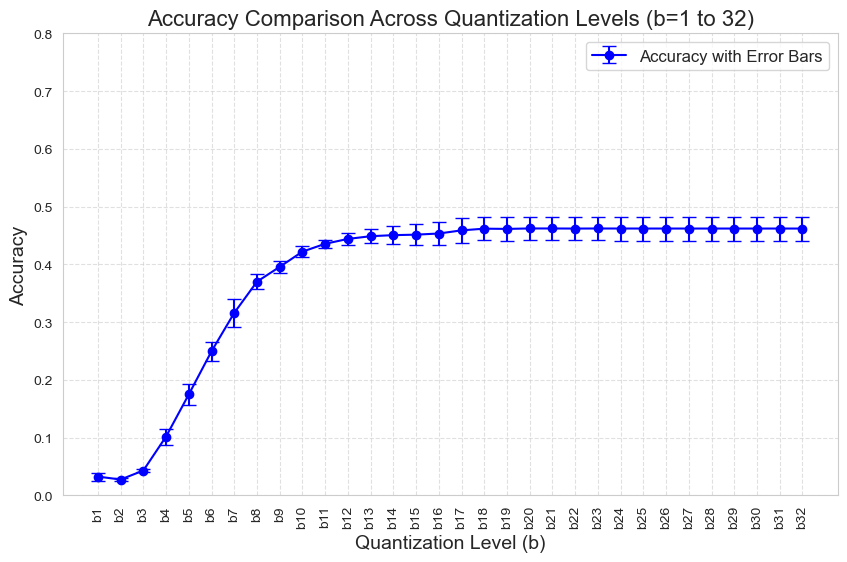

In [2]:
# identification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        F1_sc = f1_score(y_test_quantized, y_pred, average='macro')
        accuracies_per_file[file_name].append(F1_sc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: F1-Score = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 0.8)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results for Each Training Set ===

--- Train on Original ---
Test b1: F1-Score = 0.1338, Std = 0.0159
Test b2: F1-Score = 0.1434, Std = 0.0114
Test b3: F1-Score = 0.1613, Std = 0.0145
Test b4: F1-Score = 0.2027, Std = 0.0250
Test b5: F1-Score = 0.2751, Std = 0.0281
Test b6: F1-Score = 0.3513, Std = 0.0446
Test b7: F1-Score = 0.5229, Std = 0.0660
Test b8: F1-Score = 0.5760, Std = 0.0359
Test b9: F1-Score = 0.6126, Std = 0.0262
Test b10: F1-Score = 0.6425, Std = 0.0414
Test b11: F1-Score = 0.6553, Std = 0.0385
Test b12: F1-Score = 0.6557, Std = 0.0463
Test b13: F1-Score = 0.6625, Std = 0.0436
Test b14: F1-Score = 0.6652, Std = 0.0419
Test b15: F1-Score = 0.6626, Std = 0.0409
Test b16: F1-Score = 0.6658, Std = 0.0406
Test b17: F1-Score = 0.6684, Std = 0.0402
Test b18: F1-Score = 0.6713, Std = 0.0417
Test b19: F1-Score = 0.6736, Std = 0.0418
Test b20: F1-Score = 0.6737, Std = 0.0419
Test b21: F1-Score = 0.6737, Std = 0.0405
Test b22: F1-Score = 0.6737, Std = 0.0404
Test b23: F1-

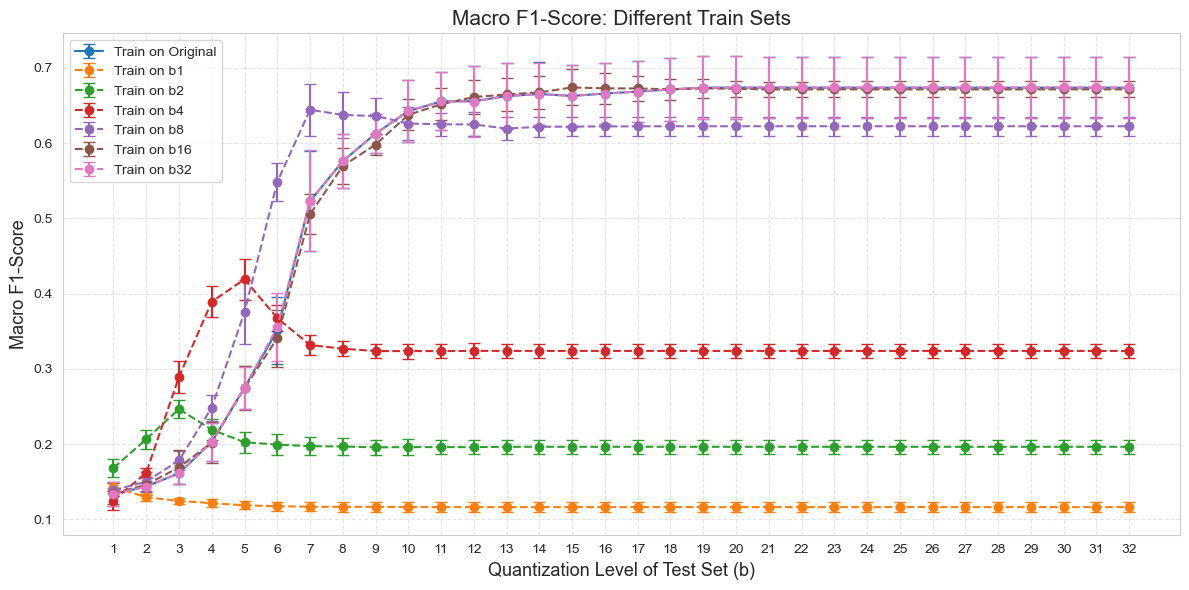

In [3]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 设置路径
base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Type"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

train_sources = {"Original": input_file_path}
for b in [1, 2, 4, 8, 16, 32]:
    train_sources[f"b{b}"] = quantized_paths[f"b{b}"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    for train_name, train_path in train_sources.items():
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Type"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        for b in b_values:
            test_path = quantized_paths[f"b{b}"]
            df_test = pd.read_csv(test_path)
            X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
            y_test = df_test["Device Type"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

            y_pred = rf_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_matrix[train_name][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))
for train_name in f1_matrix:
    plt.errorbar(
        b_values,
        mean_f1_matrix[train_name],
        yerr=std_f1_matrix[train_name],
        label=f"Train on {train_name}",
        capsize=4,
        marker='o',
        linestyle='--' if train_name != "Original" else '-'
    )
print("\n=== Final Results for Each Training Set ===")
for train_name in mean_f1_matrix:
    print(f"\n--- Train on {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Macro F1-Score: Different Train Sets", fontsize=15)
plt.xlabel("Quantization Level of Test Set (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



=== Final Results for Each Training Set ===

--- Train on Original ---
Test b1: F1-Score = 0.0327, Std = 0.0068
Test b2: F1-Score = 0.0276, Std = 0.0018
Test b3: F1-Score = 0.0432, Std = 0.0029
Test b4: F1-Score = 0.1020, Std = 0.0138
Test b5: F1-Score = 0.1750, Std = 0.0186
Test b6: F1-Score = 0.2497, Std = 0.0169
Test b7: F1-Score = 0.3162, Std = 0.0240
Test b8: F1-Score = 0.3702, Std = 0.0133
Test b9: F1-Score = 0.3959, Std = 0.0099
Test b10: F1-Score = 0.4222, Std = 0.0099
Test b11: F1-Score = 0.4358, Std = 0.0068
Test b12: F1-Score = 0.4442, Std = 0.0103
Test b13: F1-Score = 0.4489, Std = 0.0119
Test b14: F1-Score = 0.4508, Std = 0.0153
Test b15: F1-Score = 0.4516, Std = 0.0179
Test b16: F1-Score = 0.4536, Std = 0.0192
Test b17: F1-Score = 0.4591, Std = 0.0214
Test b18: F1-Score = 0.4620, Std = 0.0204
Test b19: F1-Score = 0.4616, Std = 0.0203
Test b20: F1-Score = 0.4624, Std = 0.0202
Test b21: F1-Score = 0.4623, Std = 0.0208
Test b22: F1-Score = 0.4622, Std = 0.0206
Test b23: F1-

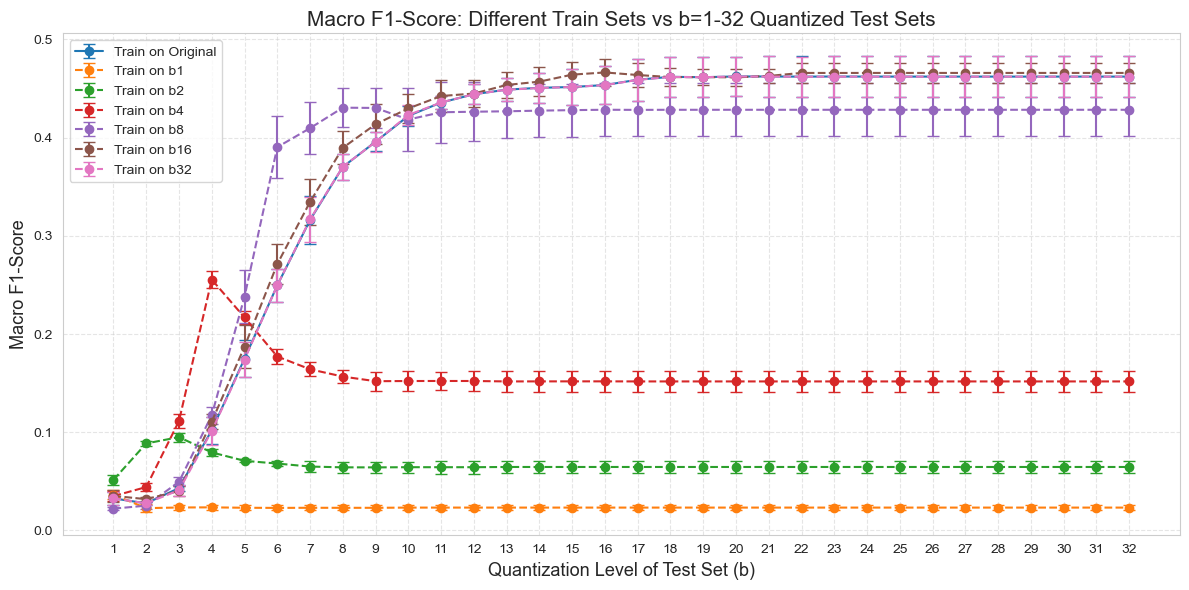

In [4]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 设置路径
base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

train_sources = {"Original": input_file_path}
for b in [1, 2, 4, 8, 16, 32]:
    train_sources[f"b{b}"] = quantized_paths[f"b{b}"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    for train_name, train_path in train_sources.items():
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        for b in b_values:
            test_path = quantized_paths[f"b{b}"]
            df_test = pd.read_csv(test_path)
            X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
            y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

            y_pred = rf_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_matrix[train_name][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))
for train_name in f1_matrix:
    plt.errorbar(
        b_values,
        mean_f1_matrix[train_name],
        yerr=std_f1_matrix[train_name],
        label=f"Train on {train_name}",
        capsize=4,
        marker='o',
        linestyle='--' if train_name != "Original" else '-'
    )
print("\n=== Final Results for Each Training Set ===")
for train_name in mean_f1_matrix:
    print(f"\n--- Train on {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Macro F1-Score: Different Train Sets vs b=1-32 Quantized Test Sets", fontsize=15)
plt.xlabel("Quantization Level of Test Set (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.0327, Std = 0.0068
Test b2: F1-Score = 0.0276, Std = 0.0018
Test b3: F1-Score = 0.0432, Std = 0.0029
Test b4: F1-Score = 0.1020, Std = 0.0138
Test b5: F1-Score = 0.1750, Std = 0.0186
Test b6: F1-Score = 0.2497, Std = 0.0169
Test b7: F1-Score = 0.3162, Std = 0.0240
Test b8: F1-Score = 0.3702, Std = 0.0133
Test b9: F1-Score = 0.3959, Std = 0.0099
Test b10: F1-Score = 0.4222, Std = 0.0099
Test b11: F1-Score = 0.4358, Std = 0.0068
Test b12: F1-Score = 0.4442, Std = 0.0103
Test b13: F1-Score = 0.4489, Std = 0.0119
Test b14: F1-Score = 0.4508, Std = 0.0153
Test b15: F1-Score = 0.4516, Std = 0.0179
Test b16: F1-Score = 0.4536, Std = 0.0192
Test b17: F1-Score = 0.4591, Std = 0.0214
Test b18: F1-Score = 0.4620, Std = 0.0204
Test b19: F1-Score = 0.4616, Std = 0.0203
Test b20: F1-Score = 0.4624, Std = 0.0202
Test b21: F1-Score = 0.4623, Std = 0.0208
Test b22: F1-Score = 0.4622, Std = 0.0206
Test b23: F1-Score = 0.4623, Std = 0.0208
Te

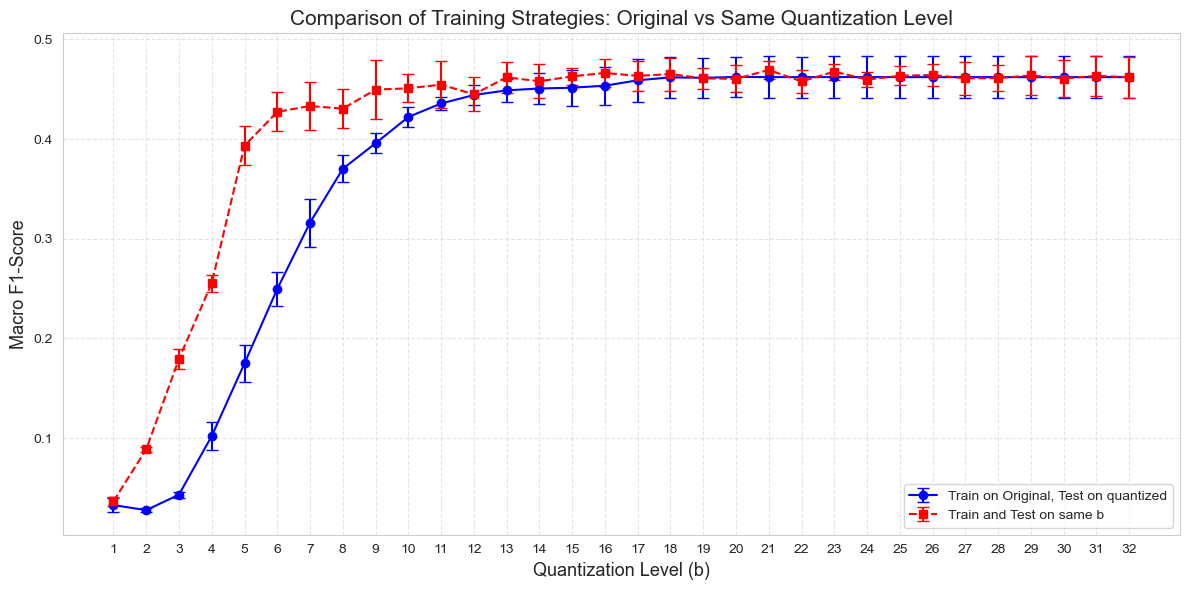

In [5]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 设置路径
base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

# 我们只需要保留Original和Same b两种情况
train_sources = {
    "Original": input_file_path,
    "Same b": None  # 特殊标记，表示训练和测试使用相同的b值
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    # 处理Original情况
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Name"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    # 处理Same b情况 - 训练和测试使用相同的b值
    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

# 绘制Original曲线
plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

# 绘制Same b曲线
plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.1338, Std = 0.0159
Test b2: F1-Score = 0.1434, Std = 0.0114
Test b3: F1-Score = 0.1613, Std = 0.0145
Test b4: F1-Score = 0.2027, Std = 0.0250
Test b5: F1-Score = 0.2751, Std = 0.0281
Test b6: F1-Score = 0.3513, Std = 0.0446
Test b7: F1-Score = 0.5229, Std = 0.0660
Test b8: F1-Score = 0.5760, Std = 0.0359
Test b9: F1-Score = 0.6126, Std = 0.0262
Test b10: F1-Score = 0.6425, Std = 0.0414
Test b11: F1-Score = 0.6553, Std = 0.0385
Test b12: F1-Score = 0.6557, Std = 0.0463
Test b13: F1-Score = 0.6625, Std = 0.0436
Test b14: F1-Score = 0.6652, Std = 0.0419
Test b15: F1-Score = 0.6626, Std = 0.0409
Test b16: F1-Score = 0.6658, Std = 0.0406
Test b17: F1-Score = 0.6684, Std = 0.0402
Test b18: F1-Score = 0.6713, Std = 0.0417
Test b19: F1-Score = 0.6736, Std = 0.0418
Test b20: F1-Score = 0.6737, Std = 0.0419
Test b21: F1-Score = 0.6737, Std = 0.0405
Test b22: F1-Score = 0.6737, Std = 0.0404
Test b23: F1-Score = 0.6736, Std = 0.0404
Te

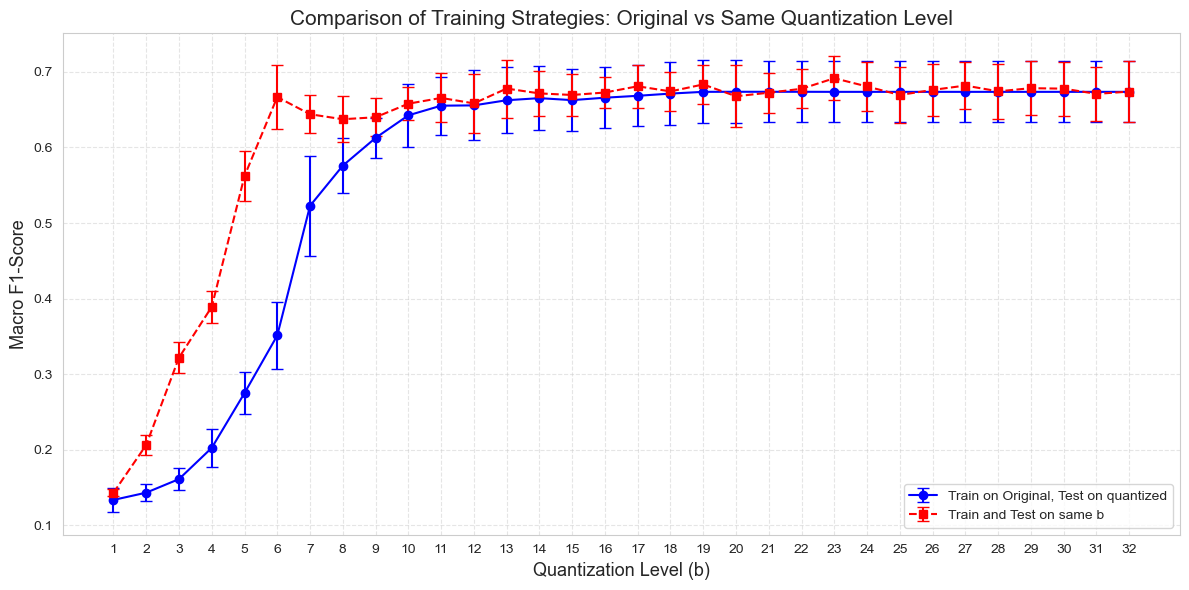

In [6]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 设置路径
base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Type"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

# 我们只需要保留Original和Same b两种情况
train_sources = {
    "Original": input_file_path,
    "Same b": None  # 特殊标记，表示训练和测试使用相同的b值
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    # 处理Original情况
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Type"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Type"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    # 处理Same b情况 - 训练和测试使用相同的b值
    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Type"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Type"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

# 绘制Original曲线
plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

# 绘制Same b曲线
plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Topology_B duration


=== Final Results ===
b1: Mean Accuracy = 0.5586, Std = 0.0002
b2: Mean Accuracy = 0.5428, Std = 0.0072
b3: Mean Accuracy = 0.5170, Std = 0.0091
b4: Mean Accuracy = 0.5615, Std = 0.0052
b5: Mean Accuracy = 0.5770, Std = 0.0096
b6: Mean Accuracy = 0.6282, Std = 0.0117
b7: Mean Accuracy = 0.6392, Std = 0.0119
b8: Mean Accuracy = 0.6512, Std = 0.0106
b9: Mean Accuracy = 0.6554, Std = 0.0114
b10: Mean Accuracy = 0.6723, Std = 0.0081
b11: Mean Accuracy = 0.6758, Std = 0.0081
b12: Mean Accuracy = 0.6811, Std = 0.0061
b13: Mean Accuracy = 0.6857, Std = 0.0084
b14: Mean Accuracy = 0.6858, Std = 0.0104
b15: Mean Accuracy = 0.6906, Std = 0.0094
b16: Mean Accuracy = 0.6931, Std = 0.0101
b17: Mean Accuracy = 0.6941, Std = 0.0095
b18: Mean Accuracy = 0.6950, Std = 0.0095
b19: Mean Accuracy = 0.6950, Std = 0.0092
b20: Mean Accuracy = 0.6949, Std = 0.0090
b21: Mean Accuracy = 0.6949, Std = 0.0089
b22: Mean Accuracy = 0.6949, Std = 0.0089
b23: Mean Accuracy = 0.6948, Std = 0.0088
b24: Mean Accuracy =

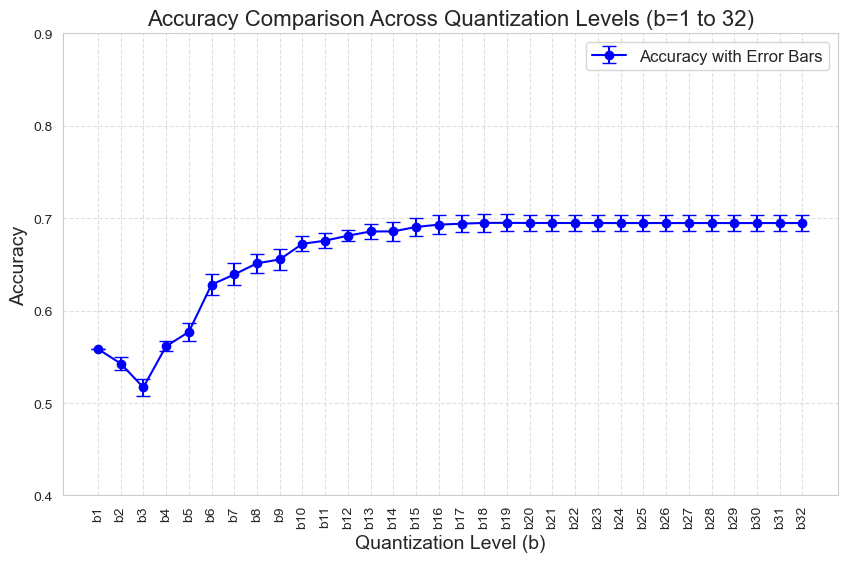

In [7]:
# classification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.4, 0.9)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results ===
b1: Mean Accuracy = 0.1454, Std = 0.0070
b2: Mean Accuracy = 0.1494, Std = 0.0029
b3: Mean Accuracy = 0.1609, Std = 0.0042
b4: Mean Accuracy = 0.1687, Std = 0.0060
b5: Mean Accuracy = 0.1767, Std = 0.0075
b6: Mean Accuracy = 0.2311, Std = 0.0085
b7: Mean Accuracy = 0.2603, Std = 0.0086
b8: Mean Accuracy = 0.2755, Std = 0.0060
b9: Mean Accuracy = 0.2823, Std = 0.0067
b10: Mean Accuracy = 0.3153, Std = 0.0064
b11: Mean Accuracy = 0.3222, Std = 0.0059
b12: Mean Accuracy = 0.3282, Std = 0.0045
b13: Mean Accuracy = 0.3378, Std = 0.0034
b14: Mean Accuracy = 0.3436, Std = 0.0026
b15: Mean Accuracy = 0.3456, Std = 0.0029
b16: Mean Accuracy = 0.3495, Std = 0.0047
b17: Mean Accuracy = 0.3505, Std = 0.0052
b18: Mean Accuracy = 0.3534, Std = 0.0043
b19: Mean Accuracy = 0.3532, Std = 0.0035
b20: Mean Accuracy = 0.3528, Std = 0.0039
b21: Mean Accuracy = 0.3529, Std = 0.0038
b22: Mean Accuracy = 0.3535, Std = 0.0036
b23: Mean Accuracy = 0.3536, Std = 0.0035
b24: Mean Accuracy =

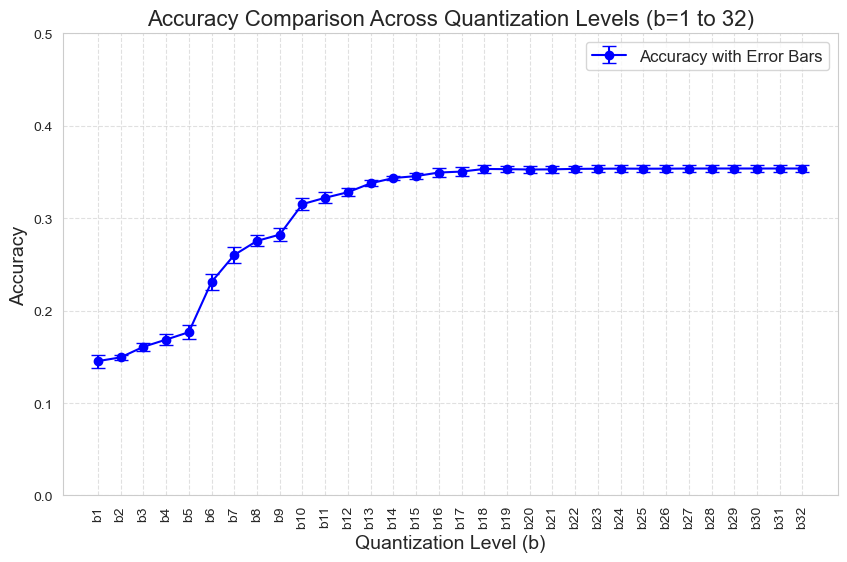

In [8]:
# identification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 0.5)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()


## Topology_A packets


=== Final Results ===
b1: Mean Accuracy = 0.5146, Std = 0.0035
b2: Mean Accuracy = 0.5409, Std = 0.0015
b3: Mean Accuracy = 0.5497, Std = 0.0143
b4: Mean Accuracy = 0.5404, Std = 0.0115
b5: Mean Accuracy = 0.5766, Std = 0.0073
b6: Mean Accuracy = 0.6155, Std = 0.0100
b7: Mean Accuracy = 0.6643, Std = 0.0097
b8: Mean Accuracy = 0.7084, Std = 0.0101
b9: Mean Accuracy = 0.7380, Std = 0.0093
b10: Mean Accuracy = 0.7657, Std = 0.0082
b11: Mean Accuracy = 0.8109, Std = 0.0066
b12: Mean Accuracy = 0.8748, Std = 0.0025
b13: Mean Accuracy = 0.8884, Std = 0.0035
b14: Mean Accuracy = 0.8954, Std = 0.0028
b15: Mean Accuracy = 0.8996, Std = 0.0036
b16: Mean Accuracy = 0.9011, Std = 0.0036
b17: Mean Accuracy = 0.9024, Std = 0.0036
b18: Mean Accuracy = 0.9034, Std = 0.0033
b19: Mean Accuracy = 0.9037, Std = 0.0033
b20: Mean Accuracy = 0.9036, Std = 0.0034
b21: Mean Accuracy = 0.9036, Std = 0.0035
b22: Mean Accuracy = 0.9036, Std = 0.0035
b23: Mean Accuracy = 0.9037, Std = 0.0036
b24: Mean Accuracy =

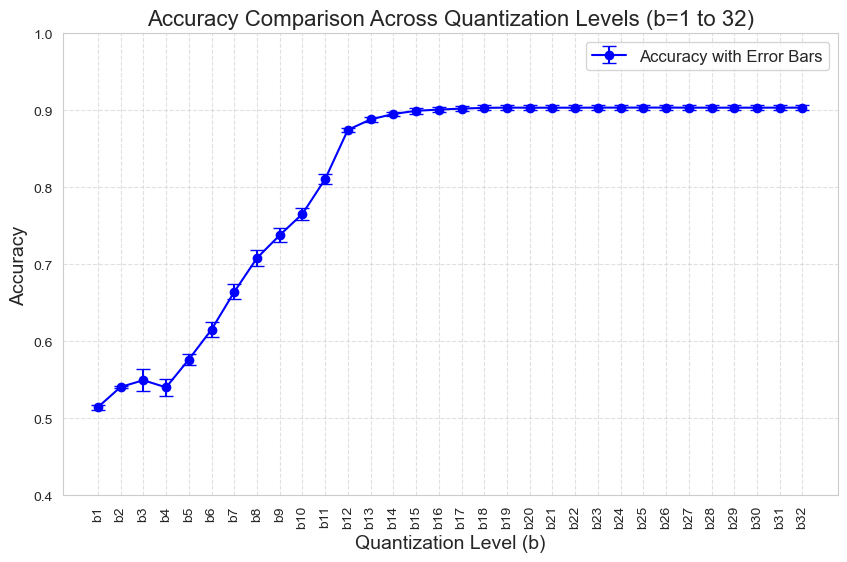

In [9]:
# classification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.4, 1)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()


D:\Anaconda\envs\compression\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



=== Final Results ===
b1: Mean Accuracy = 0.1435, Std = 0.0065
b2: Mean Accuracy = 0.1570, Std = 0.0054
b3: Mean Accuracy = 0.1739, Std = 0.0077
b4: Mean Accuracy = 0.2004, Std = 0.0061
b5: Mean Accuracy = 0.2531, Std = 0.0028
b6: Mean Accuracy = 0.3325, Std = 0.0040
b7: Mean Accuracy = 0.4098, Std = 0.0047
b8: Mean Accuracy = 0.4793, Std = 0.0049
b9: Mean Accuracy = 0.5374, Std = 0.0063
b10: Mean Accuracy = 0.5802, Std = 0.0055
b11: Mean Accuracy = 0.6311, Std = 0.0051
b12: Mean Accuracy = 0.6955, Std = 0.0070
b13: Mean Accuracy = 0.7187, Std = 0.0046
b14: Mean Accuracy = 0.7432, Std = 0.0038
b15: Mean Accuracy = 0.7622, Std = 0.0039
b16: Mean Accuracy = 0.7708, Std = 0.0040
b17: Mean Accuracy = 0.7758, Std = 0.0035
b18: Mean Accuracy = 0.7774, Std = 0.0037
b19: Mean Accuracy = 0.7788, Std = 0.0037
b20: Mean Accuracy = 0.7787, Std = 0.0035
b21: Mean Accuracy = 0.7788, Std = 0.0035
b22: Mean Accuracy = 0.7789, Std = 0.0034
b23: Mean Accuracy = 0.7790, Std = 0.0033
b24: Mean Accuracy =

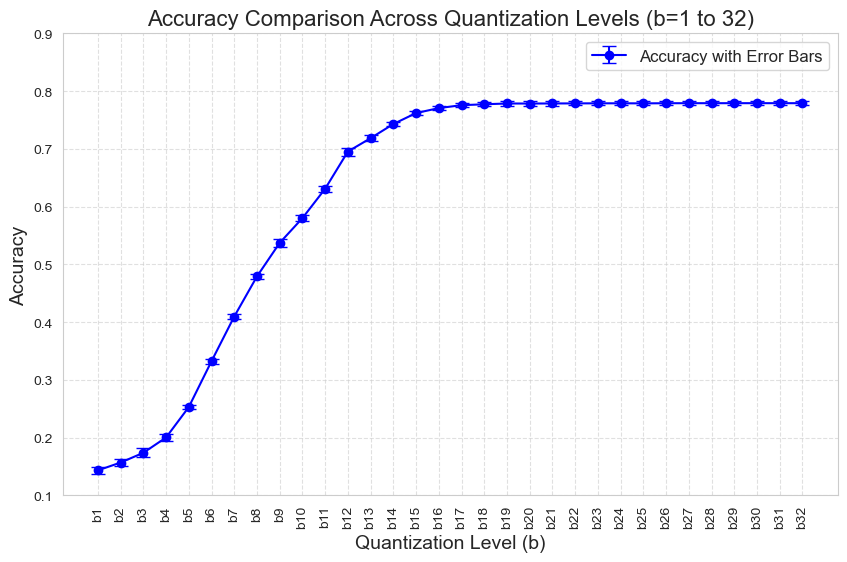

In [10]:
# identification
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_A_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.1, 0.9)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()


## Topology_B packets


=== Final Results ===
b1: Mean Accuracy = 0.6123, Std = 0.0568
b2: Mean Accuracy = 0.6363, Std = 0.0195
b3: Mean Accuracy = 0.5757, Std = 0.0166
b4: Mean Accuracy = 0.6258, Std = 0.0154
b5: Mean Accuracy = 0.6285, Std = 0.0073
b6: Mean Accuracy = 0.7000, Std = 0.0046
b7: Mean Accuracy = 0.7440, Std = 0.0053
b8: Mean Accuracy = 0.7952, Std = 0.0067
b9: Mean Accuracy = 0.8210, Std = 0.0070
b10: Mean Accuracy = 0.8591, Std = 0.0047
b11: Mean Accuracy = 0.8671, Std = 0.0043
b12: Mean Accuracy = 0.8733, Std = 0.0040
b13: Mean Accuracy = 0.8980, Std = 0.0016
b14: Mean Accuracy = 0.9083, Std = 0.0016
b15: Mean Accuracy = 0.9161, Std = 0.0018
b16: Mean Accuracy = 0.9258, Std = 0.0017
b17: Mean Accuracy = 0.9279, Std = 0.0019
b18: Mean Accuracy = 0.9288, Std = 0.0025
b19: Mean Accuracy = 0.9289, Std = 0.0027
b20: Mean Accuracy = 0.9291, Std = 0.0026
b21: Mean Accuracy = 0.9292, Std = 0.0026
b22: Mean Accuracy = 0.9291, Std = 0.0027
b23: Mean Accuracy = 0.9291, Std = 0.0026
b24: Mean Accuracy =

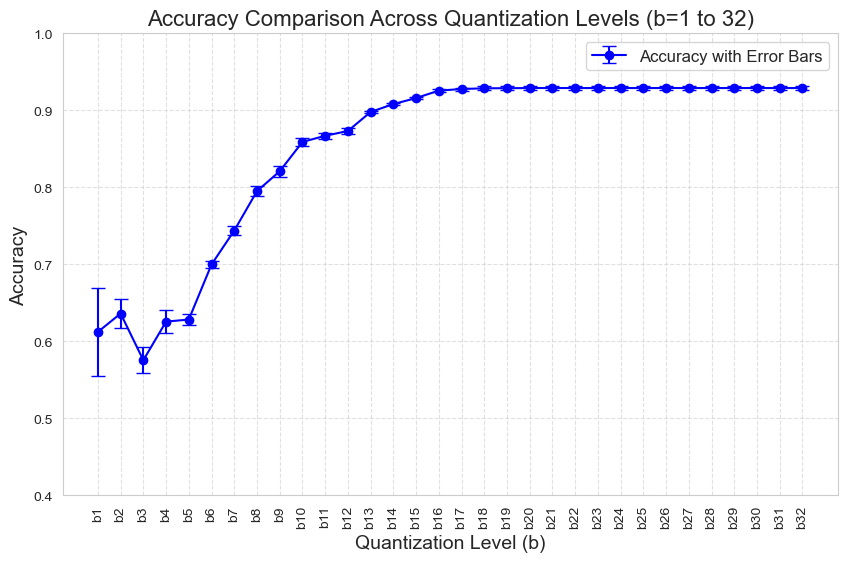

In [11]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Type"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Type"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.4, 1)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()



=== Final Results ===
b1: Mean Accuracy = 0.2473, Std = 0.0032
b2: Mean Accuracy = 0.2442, Std = 0.0052
b3: Mean Accuracy = 0.2160, Std = 0.0053
b4: Mean Accuracy = 0.2537, Std = 0.0107
b5: Mean Accuracy = 0.2767, Std = 0.0108
b6: Mean Accuracy = 0.3463, Std = 0.0137
b7: Mean Accuracy = 0.4062, Std = 0.0150
b8: Mean Accuracy = 0.4906, Std = 0.0126
b9: Mean Accuracy = 0.5540, Std = 0.0125
b10: Mean Accuracy = 0.6199, Std = 0.0074
b11: Mean Accuracy = 0.6399, Std = 0.0054
b12: Mean Accuracy = 0.6541, Std = 0.0051
b13: Mean Accuracy = 0.6991, Std = 0.0038
b14: Mean Accuracy = 0.7246, Std = 0.0021
b15: Mean Accuracy = 0.7367, Std = 0.0029
b16: Mean Accuracy = 0.7564, Std = 0.0024
b17: Mean Accuracy = 0.7628, Std = 0.0023
b18: Mean Accuracy = 0.7690, Std = 0.0024
b19: Mean Accuracy = 0.7709, Std = 0.0017
b20: Mean Accuracy = 0.7717, Std = 0.0016
b21: Mean Accuracy = 0.7721, Std = 0.0014
b22: Mean Accuracy = 0.7722, Std = 0.0018
b23: Mean Accuracy = 0.7721, Std = 0.0018
b24: Mean Accuracy =

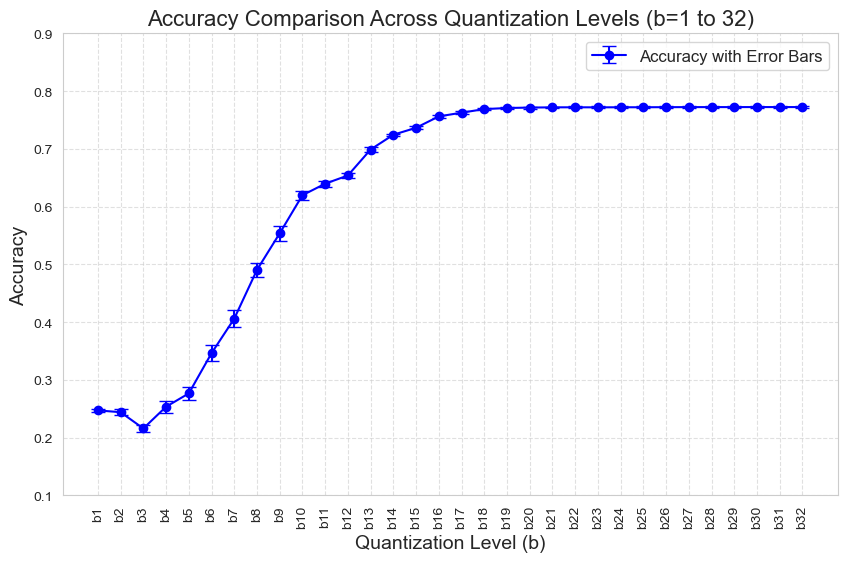

In [12]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def quantize(data, b):
    min_val = data.min()
    max_val = data.max()

    levels = 2 ** b
    step = (max_val - min_val) / levels

    quantized_indexes = np.floor((data - min_val) / step)
    quantized_indexes = np.clip(quantized_indexes, 0, levels - 1)

    quantized_data = quantized_indexes * step + min_val
    return quantized_data, quantized_indexes

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
output_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")
output_folder2 = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_index")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_folder2, exist_ok=True)

b_values = list(range(1, 33))  # b be from 1 to 32.

file_name = "Topology_B_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)
df = pd.read_csv(input_file_path)
columns_to_quantize = df.columns[3:10]

for b in b_values:
    try:
        quantized_df = df.copy()
        index_df = df.copy()
        for col in columns_to_quantize:
            quantized_values, quantized_indexes = quantize(df[col].values, b)
            quantized_df[col] = quantized_values
            index_df[col] = quantized_indexes

        new_file_name = file_name.replace(".csv", "")
        output_file = os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv")
        output_index_file = os.path.join(output_folder2, f"{new_file_name}_index_b{b}.csv")

        quantized_df.to_csv(output_file, index=False)
        index_df.to_csv(output_index_file, index=False)
    except MemoryError:
        print(f"Quantization failed for b={b}")

file_paths = {f"b{b}": os.path.join(output_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = os.path.join(input_folder, file_name)

folds = 5
accuracies_per_file = {file_name: [] for file_name in file_paths.keys() if file_name != "Original"}

original_data = pd.read_csv(file_paths["Original"])
X_original = original_data.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = original_data["Device Name"]
y_original = y_original.astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

for train_indices, test_indices in skf.split(X_original, y_original):
    X_train, X_test = X_original.iloc[train_indices], X_original.iloc[test_indices]
    y_train, y_test_original = y_original[train_indices], y_original[test_indices]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    for file_name, file_path in file_paths.items():
        if file_name == "Original":
            continue

        quantized_data = pd.read_csv(file_path)
        X_test_quantized = quantized_data.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_indices]
        y_test_quantized = quantized_data["Device Name"].iloc[test_indices]
        y_test_quantized = y_test_quantized.astype("category")
        y_test_quantized = y_test_quantized.cat.set_categories(categories).cat.codes

        y_pred = rf_model.predict(X_test_quantized)
        acc = accuracy_score(y_test_quantized, y_pred)
        accuracies_per_file[file_name].append(acc)

mean_accuracies = {file_name: np.mean(accs) for file_name, accs in accuracies_per_file.items()}
std_accuracies = {file_name: np.std(accs) for file_name, accs in accuracies_per_file.items()}

print("\n=== Final Results ===")
for file_name, mean_acc in sorted(mean_accuracies.items(), key=lambda x: int(x[0][1:])):
    print(f"{file_name}: Mean Accuracy = {mean_acc:.4f}, Std = {std_accuracies[file_name]:.4f}")

plt.figure(figsize=(10, 6))
b_values_sorted = sorted(mean_accuracies.keys(), key=lambda x: int(x[1:]))
plt.errorbar(
    b_values_sorted,
    [mean_accuracies[b] for b in b_values_sorted],
    yerr=[std_accuracies[b] for b in b_values_sorted],
    fmt="o-", capsize=5, label="Accuracy with Error Bars", color="blue",
)
plt.title("Accuracy Comparison Across Quantization Levels (b=1 to 32)", fontsize=16)
plt.xlabel("Quantization Level (b)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.1, 0.9)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()


<>:6: SyntaxWarning: invalid escape sequence '\Z'
<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:6: SyntaxWarning: invalid escape sequence '\Z'
<>:7: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\郑大林\AppData\Local\Temp\ipykernel_34416\1846402116.py:6: SyntaxWarning: invalid escape sequence '\Z'
  df_original = pd.read_csv("D:\ZBIOT-2025\Dataset\Merged_Data\A_6-Merged_sequence_data_fix_durations\Topology_A_fix_duration.csv")
C:\Users\郑大林\AppData\Local\Temp\ipykernel_34416\1846402116.py:7: SyntaxWarning: invalid escape sequence '\Z'
  df_b8 = pd.read_csv("D:\ZBIOT-2025\Dataset\Quantized_Data\A_6-Merged_sequence_data_fix_durations\Quantized_values\Topology_A_fix_duration_value_b8.csv")


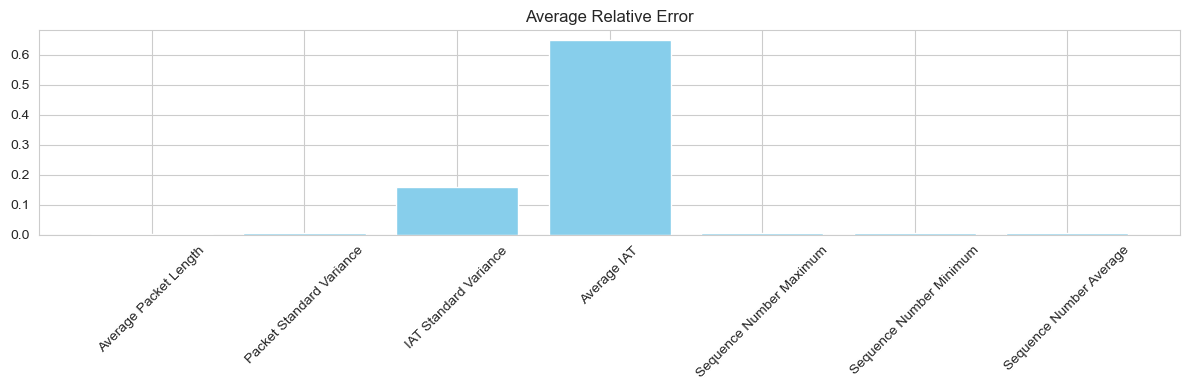

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 原始数据和量化后的数据（按相同行对齐）
df_original = pd.read_csv("D:\ZBIOT-2025\Dataset\Merged_Data\A_6-Merged_sequence_data_fix_durations\Topology_A_fix_duration.csv")
df_b8 = pd.read_csv("D:\ZBIOT-2025\Dataset\Quantized_Data\A_6-Merged_sequence_data_fix_durations\Quantized_values\Topology_A_fix_duration_value_b8.csv")

# 要比较的数值特征
features = ["Average Packet Length", "Packet Standard Variance", "IAT Standard Variance", "Average IAT",
            "Sequence Number Maximum", "Sequence Number Minimum", "Sequence Number Average"]

# 用于保存每列误差
abs_errors = {}
rel_errors = {}
mse_scores = {}

for feature in features:
    orig = df_original[feature].values
    quant = df_b8[feature].values

    abs_errors[feature] = np.mean(np.abs(quant - orig))
    rel_errors[feature] = np.mean(np.abs((quant - orig) / (orig + 1e-8)))
    mse_scores[feature] = np.mean((quant - orig)**2)

# 可视化比较
plt.figure(figsize=(12, 4))

plt.bar(features, rel_errors.values(), color='skyblue')
plt.title("Average Relative Error")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
